In [1]:
# initialize stuff
import sys
import logging
import importlib

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.optimize import curve_fit

# import theory stuff

HOME_DIR = "/Users/oliver/Documents/p5control-bluefors-evaluation"
sys.path.append(HOME_DIR)

import superconductivity.api as sc

from superconductivity.style.cpd4 import cmap, colors

from superconductivity.utilities.functions import bin_y_over_x, upsample

from superconductivity.utilities.constants import G_0_muS


from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

In [2]:
# Initial guessing parameter
tau_0_arbu: float = 0.18877592218372993
Delta_0_meV: float = 0.19345000789195935
Gamma_0_meV: float = 0.005066874981090785

tau_0_err_arbu: float = 8.141661166363163e-06
Delta_0_err_meV: float = 0.001046070192372882
Gamma_0_err_meV: float = 0.00022303789162508994

# --- paramters ---
# τ = 0.18877592218372993 (8.141661166363163e-06)
# Δ = 0.19345000789195935 (0.001046070192372882) mV
# Γ = 0.005066874981090785 (0.00022303789162508994) mV

T_0_K: float = 0.08
# Data
nu_GHz = 13.6  # n = perfect, slight gap closing
A_mV: NDArray[np.float64] = np.arange(0, 1.5, 0.002, dtype="float64")

V: NDArray[np.float64] = np.linspace(-9.5, 9.5, 801, dtype="float64")
V_mV = V * Delta_0_meV
V_off_range_mV: NDArray[np.float64] = np.linspace(-0.045, 0.045, 451, dtype="float64")

I_nA: NDArray[np.float64] = np.linspace(-30, 30, 601, dtype="float64")
I_off_range_nA: NDArray[np.float64] = np.linspace(-0.35, 0.35, 701, dtype="float64")

# exp_data evaluation
sampling_rate: float = 13.7
window_length: int = 0

# interesting Amplitudes
A_lim_mV: tuple[float, float] = (0, 705)  # mV
A_interest_mV: list[float] = [0, 100, 250, 400]  # mV

# PAT parameter
# nu_GHz: float = 7.8  # n = many, gap closing
# nu_GHz: float = 8.0  # n = inf, ever so slight gap closing
# nu_GHz: float = 15.0 # n = 2, crap
# nu_GHz: float = 18.3  # n = okay, slight gap closing
# nu_GHz: float = 19.3 # n = 3, crap

G_N = tau_0_arbu


def calibration_A(x_data: NDArray[np.float64], eta: float, A_off: float):
    A_cal = A_off + eta * x_data
    return A_cal


def calibration_T(
    x_data: NDArray[np.float64], T_base: float, T_off: float, alpha: float
):
    x_data = T_off + alpha * x_data
    return np.where(x_data <= T_base, T_base, x_data)


eta = 0.002173  # (3)
A_off = -6.2e-3  # (13) mV
T_base = 0.0806  # (46) K
T_off = -0.685  # (194) K
alpha = 2.6811  # (458)

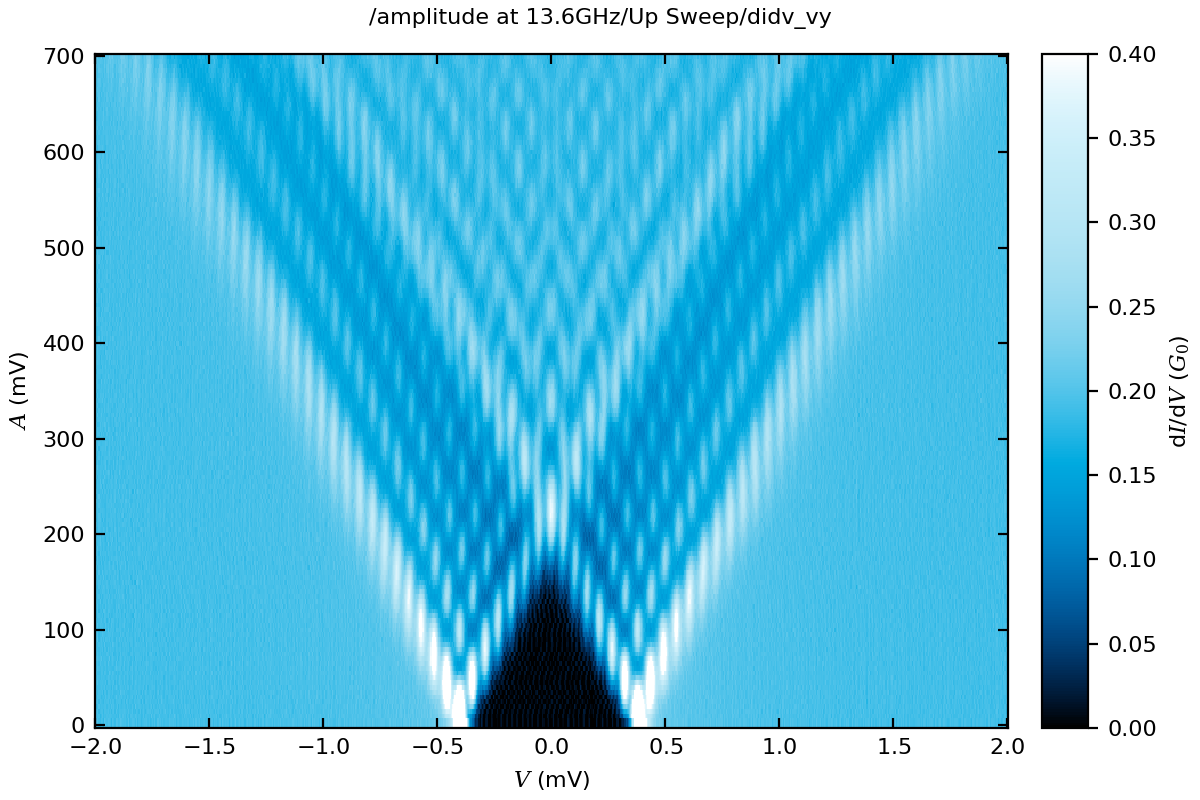

In [3]:
# plot and load exp data
%matplotlib inline
from utilities.ivplot import IVPlot
importlib.reload(sys.modules["utilities.ivplot"])
logger = logging.getLogger()
logger.setLevel(level=logging.WARNING)

eva = IVPlot()
eva.title = f"amplitude at {nu_GHz:.1f}GHz"
eva.sub_folder = ""
eva.loadData()
eva.to_plot = eva.up_sweep
eva.title_of_plot = "Up Sweep"
eva.y_characters = [r"$A$", "V"]
eva.dvdi_norm = (1e3, 'k')
eva.didv_c_lim = (0, 0.4)
eva.dvdi_c_lim = (0, 0.4e6)
if window_length >2:
    eva.smoothing = True
    eva.window_length = window_length
else:
    eva.smoothing = False
eva.plot_T = False
eva.plot_dvdis = False
eva.plot_didvs = True
eva.plot_all()

In [ ]:
x = eva.mapped["voltage_axis"]
y = eva.mapped["y_axis"]
z = eva.up_sweep["differential_conductance"]

In [21]:
x = np.linspace(-6, 6, 501)
y = np.linspace(-5, 5, 401)
X, Y = np.meshgrid(x, y, indexing="xy")

z = (
    1.0 * np.exp(-((X + 2.2) ** 2 + (Y + 0.4) ** 2) / 1.2**2)
    + 0.8 * np.exp(-((X - 0.3) ** 2 + (Y - 0.8) ** 2) / 1.0**2)
    + 0.9 * np.exp(-((X - 2.4) ** 2 + (Y + 1.0) ** 2) / 1.4**2)
)

In [22]:
from superconductivity.visuals.relief import extract_visible_relief

In [ ]:
extract_visible_relief(
    x=x,
    y=y,
    z=z,
    observer=(x.min(), y.min(), z.max()),
    target=(0, 0, 0),
)

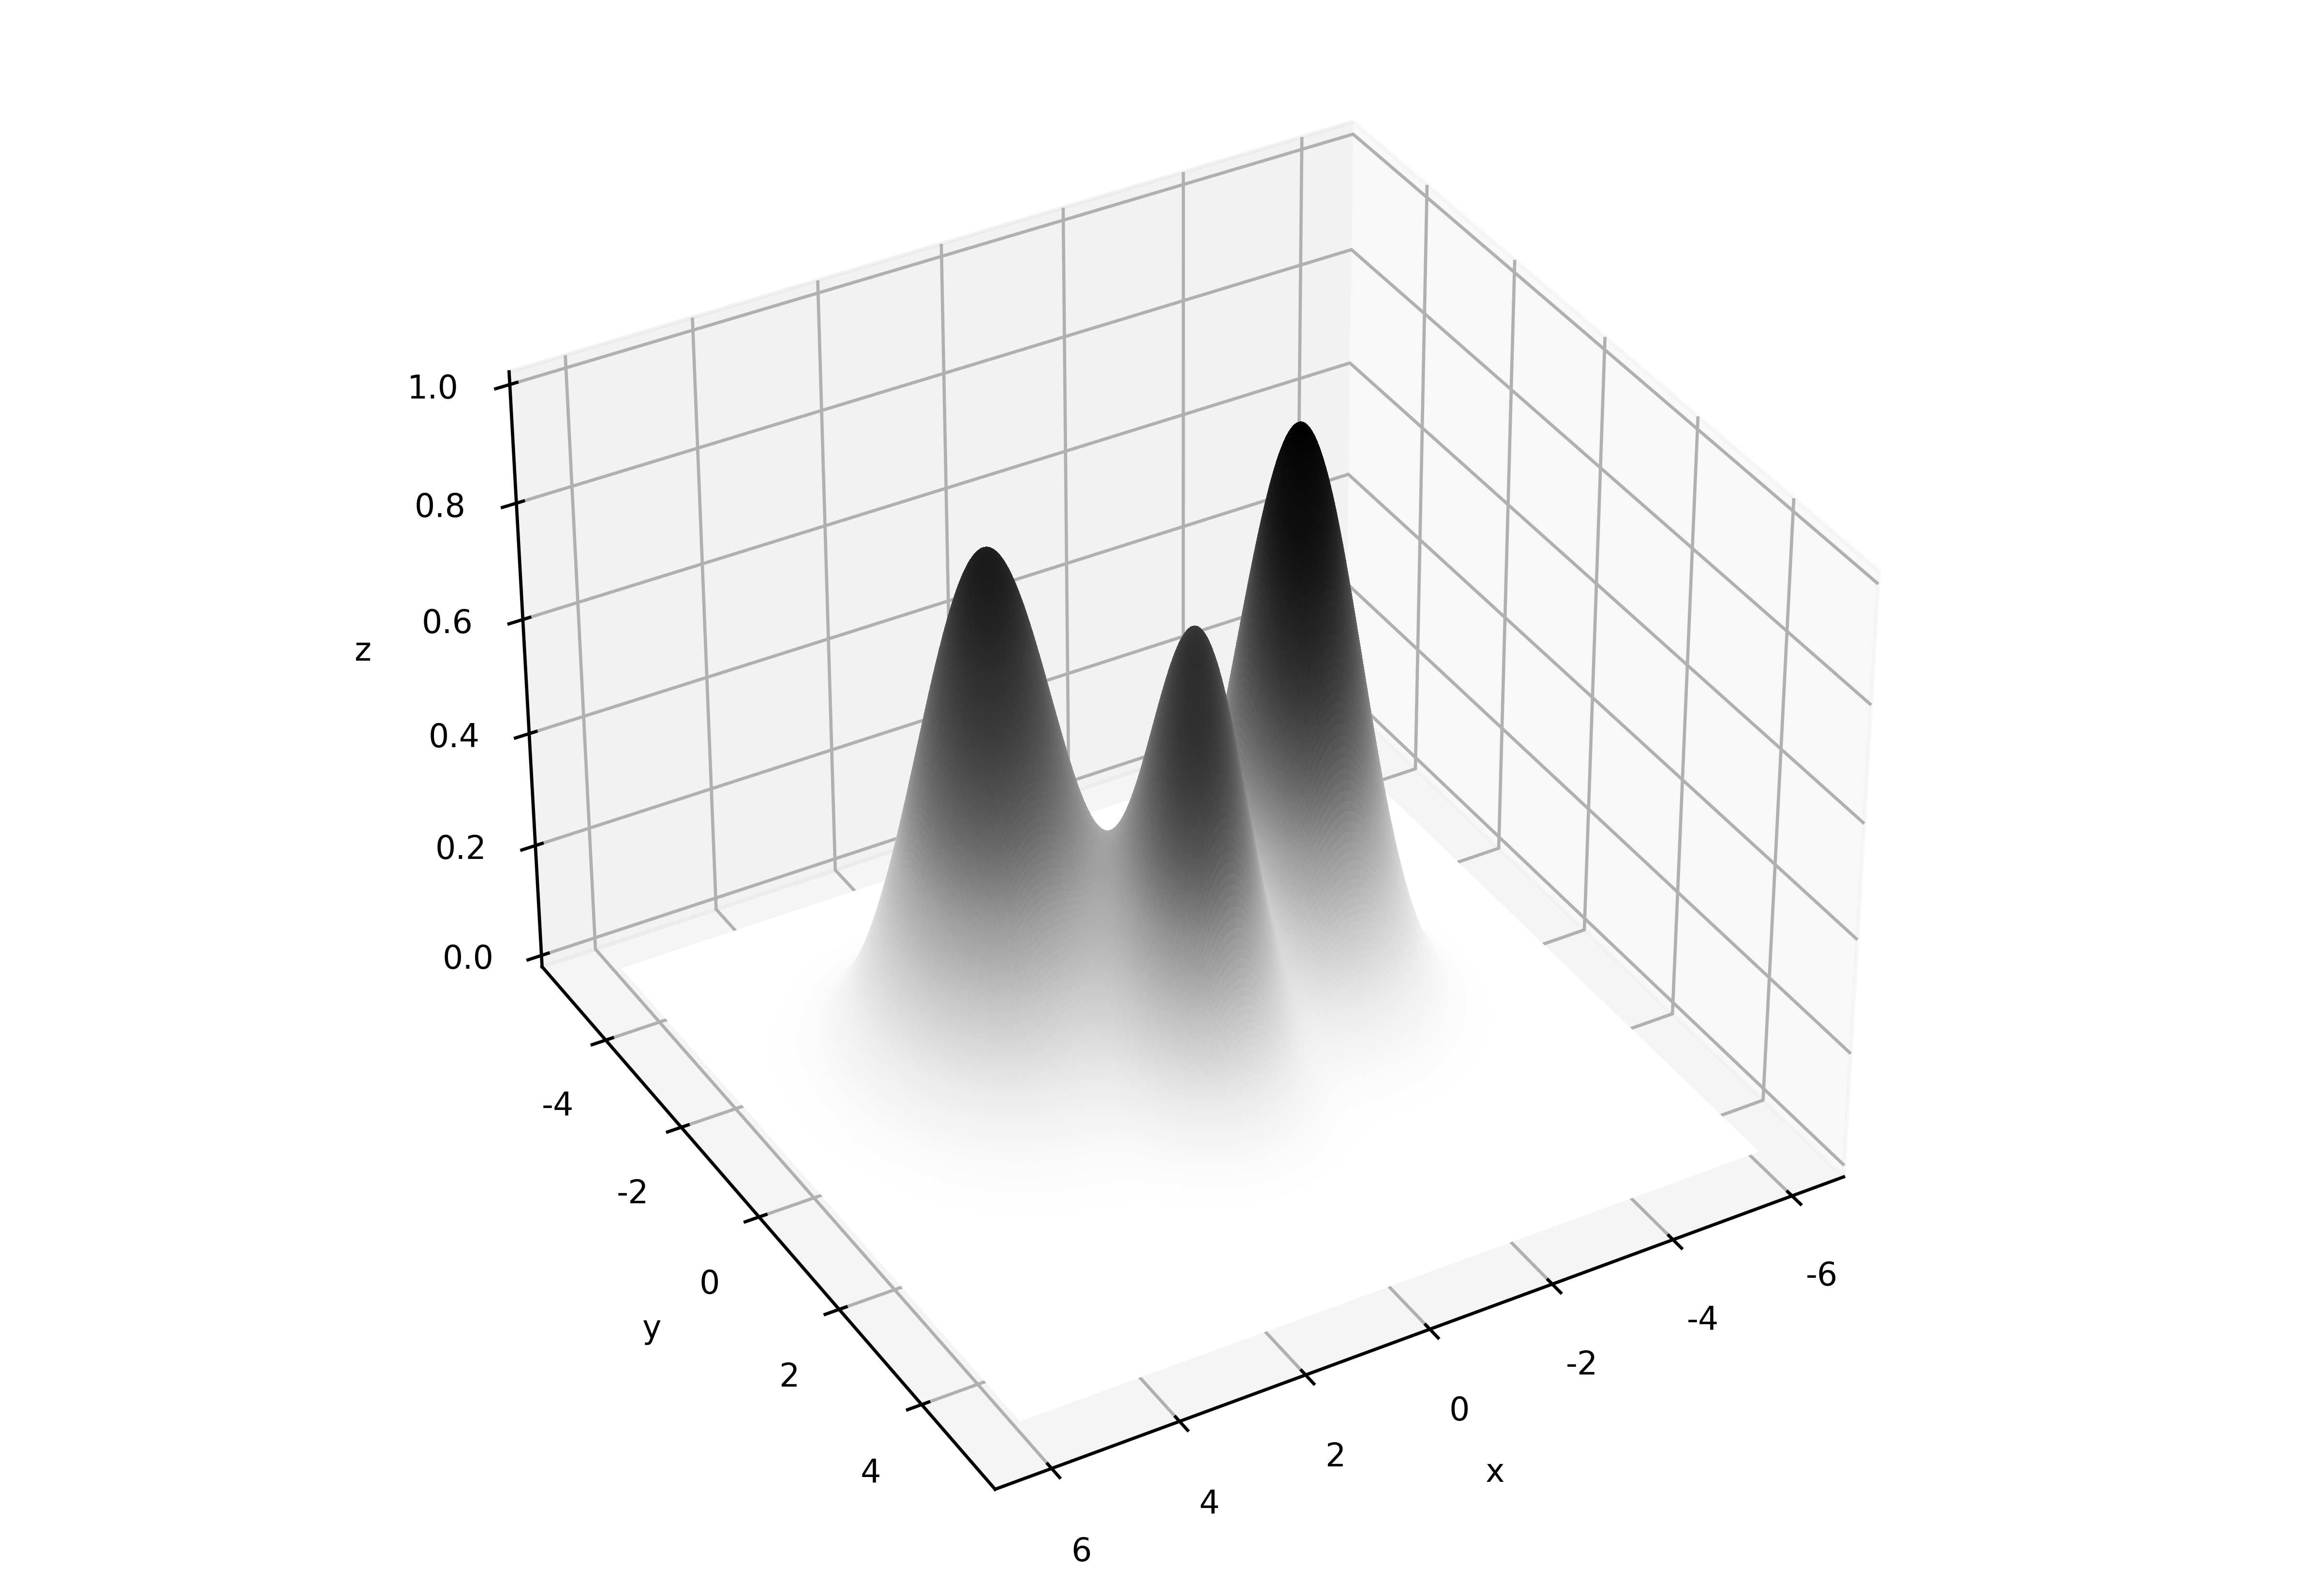

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

fig = plt.figure(figsize=(8, 5.5))
ax = fig.add_subplot(111, projection="3d")

ls = LightSource(azdeg=325, altdeg=35)
facecolors = ls.shade(
    Z,
    cmap=plt.cm.Greys,
    vert_exag=0.8,
    blend_mode="soft",
)

ax.plot_surface(
    X,
    Y,
    Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
)

ax.view_init(elev=35, azim=60)
# ax.set_box_aspect((x.ptp(), y.ptp(), 2.2 * Z.ptp()))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def plot_heatmap_with_viewpoint(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    azim_deg: float = 45.0,
    arrow_length_frac: float = 0.18,
    ax: plt.Axes | None = None,
):
    """
    Plot a heatmap with a clearly defined viewing direction.

    Convention
    ----------
    azim_deg = 0   -> looking toward +x
    azim_deg = 90  -> looking toward +y

    The arrow shows the direction from observer into the scene.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    else:
        fig = ax.figure

    im = ax.imshow(
        z,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto",
        cmap="viridis",
    )
    fig.colorbar(im, ax=ax, label="height z")

    # arrow anchor near the center
    xc = 0.5 * (x.min() + x.max())
    yc = 0.5 * (y.min() + y.max())

    dx_total = x.max() - x.min()
    dy_total = y.max() - y.min()
    L = arrow_length_frac * min(dx_total, dy_total)

    phi = np.deg2rad(azim_deg)
    dx = L * np.cos(phi)
    dy = L * np.sin(phi)

    ax.arrow(
        xc,
        yc,
        dx,
        dy,
        color="red",
        width=0.01 * L,
        head_width=0.08 * L,
        head_length=0.10 * L,
        length_includes_head=True,
        zorder=5,
    )

    ax.text(
        xc + 1.1 * dx,
        yc + 1.1 * dy,
        "view direction",
        color="red",
        fontsize=10,
        ha="left",
        va="bottom",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Heatmap with viewpoint, azim = {azim_deg:.1f}°")

    return fig, ax

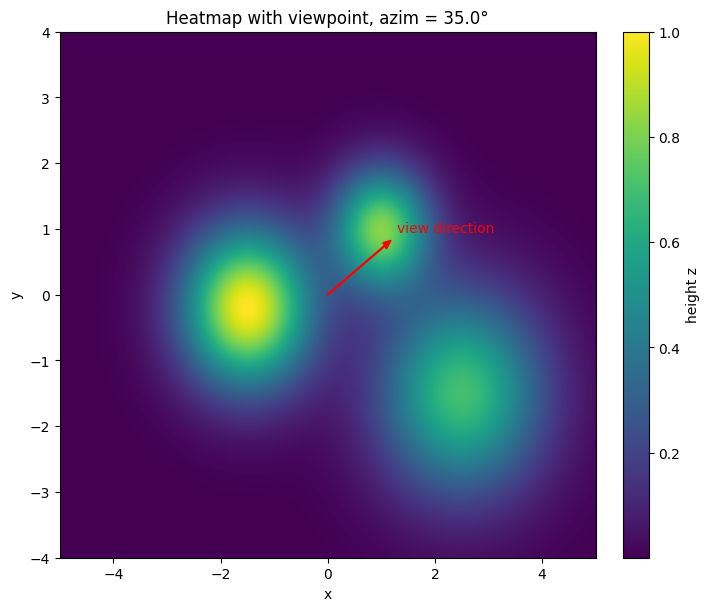

In [2]:
x = np.linspace(-5, 5, 401)
y = np.linspace(-4, 4, 321)
X, Y = np.meshgrid(x, y, indexing="xy")

Z = (
    1.0 * np.exp(-((X + 1.5) ** 2 + (Y + 0.2) ** 2) / 1.2**2)
    + 0.8 * np.exp(-((X - 1.0) ** 2 + (Y - 1.0) ** 2) / 0.9**2)
    + 0.7 * np.exp(-((X - 2.5) ** 2 + (Y + 1.5) ** 2) / 1.5**2)
)

plot_heatmap_with_viewpoint(x, y, Z, azim_deg=35)
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def plot_heatmap_with_camera(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    azim_deg: float = 45.0,
    elev_deg: float = 25.0,
    observer_offset_frac: float = 0.18,
    ax: plt.Axes | None = None,
):
    """
    Plot heatmap with an explicit observer position and view direction.

    Convention
    ----------
    azim_deg = 0   : looking toward +x
    azim_deg = 90  : looking toward +y

    The observer is placed outside the map in the opposite direction of
    the view arrow.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    else:
        fig = ax.figure

    im = ax.imshow(
        z,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto",
        cmap="viridis",
    )
    fig.colorbar(im, ax=ax, label="height z")

    # Map center and scale
    xc = 0.5 * (x.min() + x.max())
    yc = 0.5 * (y.min() + y.max())
    dx_total = x.max() - x.min()
    dy_total = y.max() - y.min()
    L = 0.22 * min(dx_total, dy_total)

    phi = np.deg2rad(azim_deg)
    vx = np.cos(phi)
    vy = np.sin(phi)

    # Observer sits outside the map opposite to viewing direction
    offset = observer_offset_frac * np.hypot(dx_total, dy_total)
    obs_x = xc - offset * vx
    obs_y = yc - offset * vy

    # Arrow points from observer into the scene
    ax.arrow(
        obs_x,
        obs_y,
        1.35 * L * vx,
        1.35 * L * vy,
        color="red",
        width=0.01 * L,
        head_width=0.08 * L,
        head_length=0.10 * L,
        length_includes_head=True,
        zorder=6,
    )

    ax.scatter(
        [obs_x],
        [obs_y],
        s=50,
        color="red",
        edgecolor="white",
        linewidth=0.8,
        zorder=7,
    )

    ax.text(
        obs_x,
        obs_y,
        f" observer\n azim={azim_deg:.0f}°, elev={elev_deg:.0f}°",
        color="red",
        fontsize=9,
        ha="right",
        va="top",
    )

    # optional faint guide rays
    for scale in (0.55, 0.85, 1.15):
        ax.plot(
            [obs_x, obs_x + scale * 2.5 * L * vx],
            [obs_y, obs_y + scale * 2.5 * L * vy],
            color="red",
            alpha=0.18,
            lw=1.0,
        )

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Heatmap with camera viewpoint")

    return fig, ax

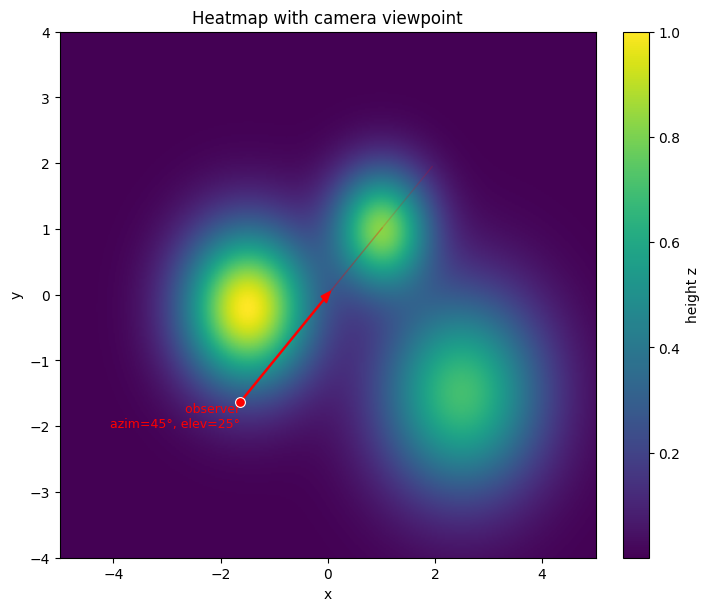

In [5]:
plot_heatmap_with_camera(
    x,
    y,
    Z,
    azim_deg=45,
    elev_deg=25,
)
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_surface_with_viewpoint_3d(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    obs_x: float | None = None,
    obs_y: float | None = None,
    obs_z: float | None = None,
    target_x: float | None = None,
    target_y: float | None = None,
    target_z: float | None = None,
    surface_stride: int = 4,
    arrow_length_frac: float = 0.25,
    elev_view_deg: float = 28.0,
    azim_view_deg: float = -60.0,
):
    """
    Plot a height field as a 3D surface together with observer and view arrow.

    Parameters
    ----------
    x, y
        1D coordinate arrays.
    z
        2D height field with shape (len(y), len(x)).
    obs_x, obs_y, obs_z
        Observer position. If omitted, place observer slightly outside the
        lower-left corner and above the plane.
    target_x, target_y, target_z
        Point the observer looks at. If omitted, use the center of the map.
    surface_stride
        Downsampling stride for the surface plot.
    arrow_length_frac
        Fraction of scene diagonal used for arrow length.
    elev_view_deg, azim_view_deg
        Matplotlib camera for inspecting the setup.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if z.shape != (y.size, x.size):
        raise ValueError(f"z must have shape ({y.size}, {x.size}), got {z.shape}")

    X, Y = np.meshgrid(x, y, indexing="xy")

    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    zmin, zmax = float(np.nanmin(z)), float(np.nanmax(z))

    dx = xmax - xmin
    dy = ymax - ymin
    dz = max(zmax - zmin, 1e-12)
    diag = np.sqrt(dx**2 + dy**2 + dz**2)

    # Default observer: outside lower-left corner, slightly elevated
    if obs_x is None:
        obs_x = xmin - 0.18 * dx
    if obs_y is None:
        obs_y = ymin - 0.18 * dy
    if obs_z is None:
        obs_z = zmin + 0.45 * dz

    # Default target: map center, slightly above mean terrain
    if target_x is None:
        target_x = 0.5 * (xmin + xmax)
    if target_y is None:
        target_y = 0.5 * (ymin + ymax)
    if target_z is None:
        target_z = zmin + 0.55 * dz

    obs = np.array([obs_x, obs_y, obs_z], dtype=float)
    tgt = np.array([target_x, target_y, target_z], dtype=float)

    direction = tgt - obs
    norm = np.linalg.norm(direction)
    if norm == 0:
        raise ValueError("Observer and target must not be identical.")
    direction /= norm

    arrow_len = arrow_length_frac * diag

    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X[::surface_stride, ::surface_stride],
        Y[::surface_stride, ::surface_stride],
        z[::surface_stride, ::surface_stride],
        linewidth=0,
        antialiased=True,
        alpha=0.75,
    )

    # Observer point
    ax.scatter(
        [obs_x],
        [obs_y],
        [obs_z],
        s=80,
        color="red",
        edgecolor="white",
        linewidth=0.8,
        label="observer",
    )

    # Target point
    ax.scatter(
        [target_x],
        [target_y],
        [target_z],
        s=40,
        color="orange",
        edgecolor="black",
        linewidth=0.6,
        label="target",
    )

    # View arrow
    ax.quiver(
        obs_x,
        obs_y,
        obs_z,
        arrow_len * direction[0],
        arrow_len * direction[1],
        arrow_len * direction[2],
        color="red",
        linewidth=2.0,
        arrow_length_ratio=0.12,
    )

    ax.text(obs_x, obs_y, obs_z, "  observer", color="red")
    ax.text(target_x, target_y, target_z, "  target", color="orange")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.view_init(elev=elev_view_deg, azim=azim_view_deg)

    # Keep aspect roughly sensible
    ax.set_box_aspect((dx, dy, 0.7 * dz))

    ax.legend(loc="upper left")
    return fig, ax

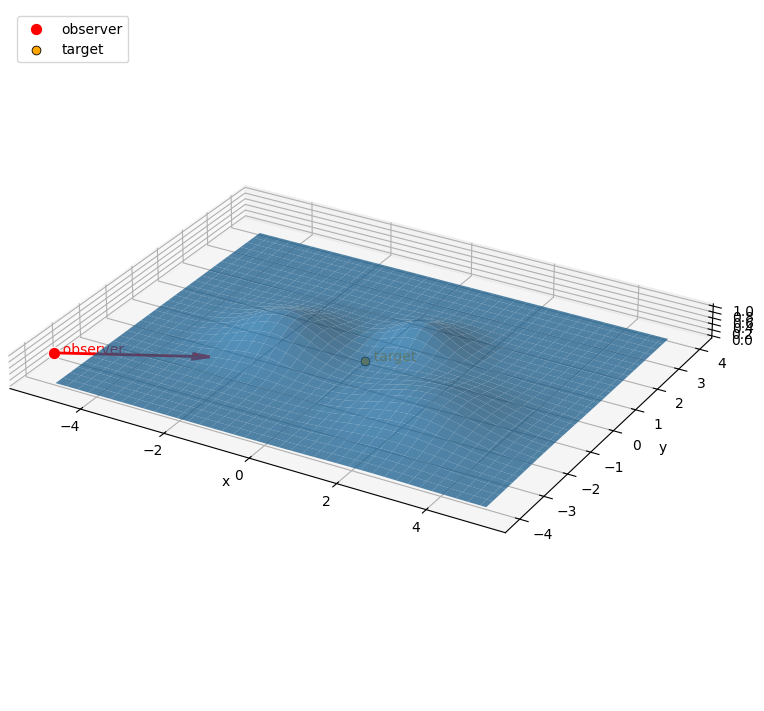

In [ ]:
x = np.linspace(-5, 5, 301)
y = np.linspace(-4, 4, 241)
X, Y = np.meshgrid(x, y, indexing="xy")

Z = (
    1.0 * np.exp(-((X + 1.8) ** 2 + (Y + 0.2) ** 2) / 1.2**2)
    + 0.85 * np.exp(-((X - 0.8) ** 2 + (Y - 1.0) ** 2) / 0.9**2)
    + 0.7 * np.exp(-((X - 2.3) ** 2 + (Y + 1.4) ** 2) / 1.5**2)
)

fig, ax = plot_surface_with_viewpoint_3d(
    x,
    y,
    Z,
    obs_x=x.min(),
    obs_y=y.min(),
    obs_z=1.0,
    target_x=0.0,
    target_y=0,
    target_z=0,
)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def plot_surface_with_observer(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    obs_x: float,
    obs_y: float,
    obs_z: float,
    target_x: float,
    target_y: float,
    target_z: float,
    surface_stride: int = 4,
    arrow_length: float | None = None,
    inspect_elev_deg: float = 28.0,
    inspect_azim_deg: float = -60.0,
):
    """
    Plot terrain surface together with observer and viewing direction.

    Notes
    -----
    The red point/arrow define the physical observer in the scene.
    The inspect_* angles only control how Matplotlib shows this setup to you.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if z.shape != (y.size, x.size):
        raise ValueError(f"z must have shape ({y.size}, {x.size}), got {z.shape}")

    X, Y = np.meshgrid(x, y, indexing="xy")

    obs = np.array([obs_x, obs_y, obs_z], dtype=float)
    tgt = np.array([target_x, target_y, target_z], dtype=float)

    forward = tgt - obs
    norm = np.linalg.norm(forward)
    if norm == 0:
        raise ValueError("Observer and target must differ.")
    forward /= norm

    if arrow_length is None:
        dx = float(x.max() - x.min())
        dy = float(y.max() - y.min())
        dz = float(np.nanmax(z) - np.nanmin(z))
        arrow_length = 0.35 * np.sqrt(dx**2 + dy**2 + dz**2)

    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X[::surface_stride, ::surface_stride],
        Y[::surface_stride, ::surface_stride],
        z[::surface_stride, ::surface_stride],
        linewidth=0,
        antialiased=True,
        alpha=0.75,
    )

    # observer
    ax.scatter(
        [obs_x],
        [obs_y],
        [obs_z],
        s=90,
        color="red",
        edgecolor="white",
        linewidth=0.8,
    )
    ax.text(obs_x, obs_y, obs_z, "  observer", color="red")

    # target
    ax.scatter(
        [target_x],
        [target_y],
        [target_z],
        s=45,
        color="orange",
        edgecolor="black",
        linewidth=0.6,
    )
    ax.text(target_x, target_y, target_z, "  target", color="orange")

    # view arrow
    ax.quiver(
        obs_x,
        obs_y,
        obs_z,
        arrow_length * forward[0],
        arrow_length * forward[1],
        arrow_length * forward[2],
        color="red",
        linewidth=2.0,
        arrow_length_ratio=0.12,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=inspect_elev_deg, azim=inspect_azim_deg)

    dx = float(x.max() - x.min())
    dy = float(y.max() - y.min())
    dz = float(np.nanmax(z) - np.nanmin(z))
    ax.set_box_aspect((dx, dy, max(0.6 * dz, 1e-6)))

    return fig, ax

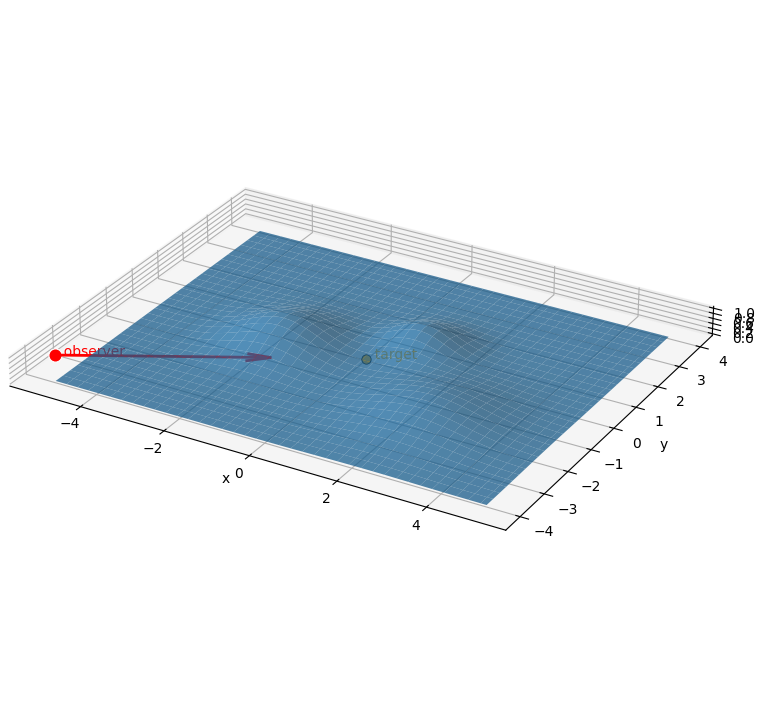

In [13]:
fig, ax = plot_surface_with_observer(
    x,
    y,
    Z,
    obs_x=x.min(),
    obs_y=y.min(),
    obs_z=1.0,
    target_x=0.0,
    target_y=0.0,
    target_z=0.0,
)
plt.show()

In [14]:
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


@dataclass
class CameraSilhouette:
    """Outer visible silhouette from an explicit observer/target camera."""

    x: np.ndarray
    y: np.ndarray
    z: np.ndarray
    u: np.ndarray
    v: np.ndarray
    cam_x: np.ndarray
    cam_y: np.ndarray
    cam_z: np.ndarray


def make_camera_basis(
    obs: np.ndarray,
    target: np.ndarray,
    up_hint: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build a right-handed camera basis.

    Returns
    -------
    right, up, forward
        Orthonormal basis vectors.
    """
    obs = np.asarray(obs, dtype=float)
    target = np.asarray(target, dtype=float)

    if up_hint is None:
        up_hint = np.array([0.0, 0.0, 1.0], dtype=float)
    else:
        up_hint = np.asarray(up_hint, dtype=float)

    forward = target - obs
    fnorm = np.linalg.norm(forward)
    if fnorm == 0:
        raise ValueError("Observer and target must differ.")
    forward = forward / fnorm

    right = np.cross(forward, up_hint)
    rnorm = np.linalg.norm(right)
    if rnorm < 1e-12:
        raise ValueError("up_hint is parallel to viewing direction.")
    right = right / rnorm

    up = np.cross(right, forward)
    up = up / np.linalg.norm(up)

    return right, up, forward


def extract_outer_silhouette_camera(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    obs_x: float,
    obs_y: float,
    obs_z: float,
    target_x: float,
    target_y: float,
    target_z: float,
    n_u_bins: int = 600,
    z_scale: float = 1.0,
) -> CameraSilhouette:
    """
    Extract the outer silhouette from an explicit observer/target camera.

    Method
    ------
    Project all terrain points into the camera frame and, for each horizontal
    image bin, keep the point with maximal vertical image coordinate.

    Parameters
    ----------
    x, y
        1D coordinate arrays.
    z
        2D height field with shape (len(y), len(x)).
    obs_*, target_*
        Observer and look-at target in world coordinates.
    n_u_bins
        Number of horizontal image bins.
    z_scale
        Optional vertical exaggeration applied before projection.

    Returns
    -------
    CameraSilhouette
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if z.shape != (y.size, x.size):
        raise ValueError(f"z must have shape ({y.size}, {x.size}), got {z.shape}")

    X, Y = np.meshgrid(x, y, indexing="xy")
    Z = z_scale * z

    obs = np.array([obs_x, obs_y, obs_z], dtype=float)
    target = np.array([target_x, target_y, target_z], dtype=float)

    right, up, forward = make_camera_basis(obs, target)

    pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    rel = pts - obs[None, :]

    cam_x = rel @ right
    cam_y = rel @ up
    cam_z = rel @ forward

    # Keep only points in front of camera
    front = cam_z > 1e-9
    if not np.any(front):
        raise ValueError("No terrain points are in front of the camera.")

    cam_x = cam_x[front]
    cam_y = cam_y[front]
    cam_z = cam_z[front]
    pts = pts[front]

    # Perspective image coordinates
    u = cam_x / cam_z
    v = cam_y / cam_z

    u_min = np.nanmin(u)
    u_max = np.nanmax(u)
    if not np.isfinite(u_min) or not np.isfinite(u_max) or u_max <= u_min:
        raise ValueError("Degenerate projected horizontal range.")

    u_edges = np.linspace(u_min, u_max, n_u_bins + 1)
    u_centers = 0.5 * (u_edges[:-1] + u_edges[1:])

    x_line = np.full(n_u_bins, np.nan, dtype=float)
    y_line = np.full(n_u_bins, np.nan, dtype=float)
    z_line = np.full(n_u_bins, np.nan, dtype=float)
    v_line = np.full(n_u_bins, np.nan, dtype=float)
    camx_line = np.full(n_u_bins, np.nan, dtype=float)
    camy_line = np.full(n_u_bins, np.nan, dtype=float)
    camz_line = np.full(n_u_bins, np.nan, dtype=float)

    bin_idx = np.digitize(u, u_edges) - 1
    valid_bins = (bin_idx >= 0) & (bin_idx < n_u_bins)

    u_valid = u[valid_bins]
    v_valid = v[valid_bins]
    pts_valid = pts[valid_bins]
    cx_valid = cam_x[valid_bins]
    cy_valid = cam_y[valid_bins]
    cz_valid = cam_z[valid_bins]
    bi_valid = bin_idx[valid_bins]

    for i in range(n_u_bins):
        mask = bi_valid == i
        if not np.any(mask):
            continue
        j = np.argmax(v_valid[mask])
        idxs = np.flatnonzero(mask)
        jj = idxs[j]

        x_line[i] = pts_valid[jj, 0]
        y_line[i] = pts_valid[jj, 1]
        z_line[i] = pts_valid[jj, 2]
        v_line[i] = v_valid[jj]
        camx_line[i] = cx_valid[jj]
        camy_line[i] = cy_valid[jj]
        camz_line[i] = cz_valid[jj]

    return CameraSilhouette(
        x=x_line,
        y=y_line,
        z=z_line,
        u=u_centers,
        v=v_line,
        cam_x=camx_line,
        cam_y=camy_line,
        cam_z=camz_line,
    )


def _split_true_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    padded = np.pad(mask.astype(int), (1, 1))
    diff = np.diff(padded)
    starts = np.flatnonzero(diff == 1)
    stops = np.flatnonzero(diff == -1)
    return list(zip(starts, stops))


def plot_heatmap_with_silhouette(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    silhouette: CameraSilhouette,
    *,
    obs_x: float,
    obs_y: float,
    target_x: float,
    target_y: float,
    ax: plt.Axes | None = None,
):
    """
    Plot top-down heatmap with observer, target, and extracted silhouette.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    else:
        fig = ax.figure

    im = ax.imshow(
        z,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto",
        cmap="viridis",
    )
    fig.colorbar(im, ax=ax, label="height z")

    # View arrow in the x-y plane
    ax.scatter([obs_x], [obs_y], s=55, color="red", edgecolor="white", linewidth=0.8)
    ax.scatter(
        [target_x], [target_y], s=35, color="orange", edgecolor="black", linewidth=0.6
    )

    ax.annotate(
        "",
        xy=(target_x, target_y),
        xytext=(obs_x, obs_y),
        arrowprops=dict(arrowstyle="->", color="red", lw=1.8),
    )

    mask = np.isfinite(silhouette.x) & np.isfinite(silhouette.y)
    for start, stop in _split_true_runs(mask):
        ax.plot(
            silhouette.x[start:stop],
            silhouette.y[start:stop],
            color="white",
            lw=2.6,
        )
        ax.plot(
            silhouette.x[start:stop],
            silhouette.y[start:stop],
            color="black",
            lw=0.9,
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Top view with observer and outer silhouette")
    return fig, ax


def plot_silhouette_profile(
    silhouette: CameraSilhouette,
    *,
    ax: plt.Axes | None = None,
):
    """
    Plot silhouette in image-plane coordinates (u, v).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    else:
        fig = ax.figure

    mask = np.isfinite(silhouette.u) & np.isfinite(silhouette.v)
    for start, stop in _split_true_runs(mask):
        ax.plot(
            silhouette.u[start:stop],
            silhouette.v[start:stop],
            color="black",
            lw=1.5,
        )

    ax.set_xlabel("image horizontal coordinate u")
    ax.set_ylabel("image vertical coordinate v")
    ax.set_title("Outer silhouette in camera image plane")
    return fig, ax

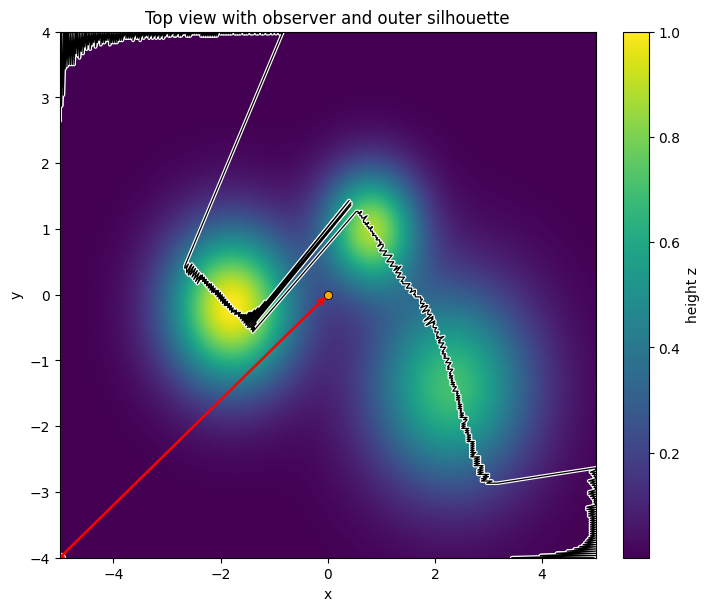

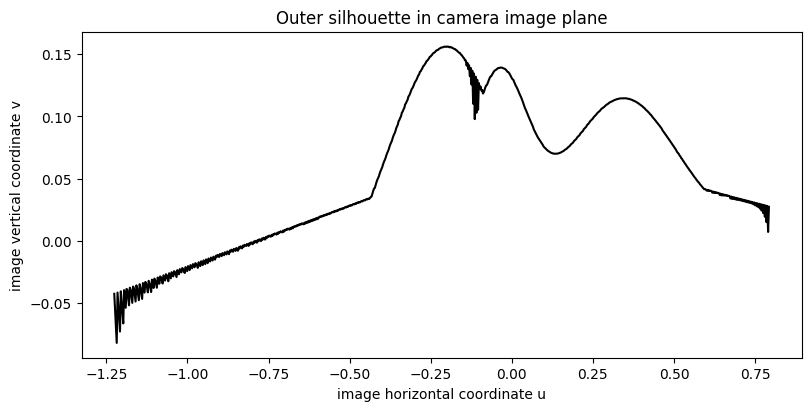

In [16]:
x = np.linspace(-5, 5, 301)
y = np.linspace(-4, 4, 241)
X, Y = np.meshgrid(x, y, indexing="xy")

Z = (
    1.0 * np.exp(-((X + 1.8) ** 2 + (Y + 0.2) ** 2) / 1.2**2)
    + 0.85 * np.exp(-((X - 0.8) ** 2 + (Y - 1.0) ** 2) / 0.9**2)
    + 0.7 * np.exp(-((X - 2.3) ** 2 + (Y + 1.4) ** 2) / 1.5**2)
)

obs_x = x.min()
obs_y = y.min()
obs_z = 1.0

target_x = 0.0
target_y = 0.0
target_z = 0.0

sil = extract_outer_silhouette_camera(
    x,
    y,
    Z,
    obs_x=obs_x,
    obs_y=obs_y,
    obs_z=obs_z,
    target_x=target_x,
    target_y=target_y,
    target_z=target_z,
    n_u_bins=800,
    z_scale=1.0,
)

plot_heatmap_with_silhouette(
    x,
    y,
    Z,
    sil,
    obs_x=obs_x,
    obs_y=obs_y,
    target_x=target_x,
    target_y=target_y,
)
plt.show()

plot_silhouette_profile(sil)
plt.show()

In [17]:
import numpy as np
from dataclasses import dataclass
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


@dataclass
class CameraSilhouette:
    x: np.ndarray
    y: np.ndarray
    z: np.ndarray
    u: np.ndarray
    v: np.ndarray


def make_camera_basis(obs, target, up_hint=None):
    obs = np.asarray(obs, dtype=float)
    target = np.asarray(target, dtype=float)

    if up_hint is None:
        up_hint = np.array([0.0, 0.0, 1.0], dtype=float)
    else:
        up_hint = np.asarray(up_hint, dtype=float)

    forward = target - obs
    forward /= np.linalg.norm(forward)

    right = np.cross(forward, up_hint)
    right /= np.linalg.norm(right)

    up = np.cross(right, forward)
    up /= np.linalg.norm(up)

    return right, up, forward


def _split_true_runs(mask: np.ndarray):
    padded = np.pad(mask.astype(int), (1, 1))
    diff = np.diff(padded)
    starts = np.flatnonzero(diff == 1)
    stops = np.flatnonzero(diff == -1)
    return list(zip(starts, stops))


def extract_outer_silhouette_camera_smooth(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    obs_x: float,
    obs_y: float,
    obs_z: float,
    target_x: float,
    target_y: float,
    target_z: float,
    n_u_bins: int = 700,
    z_scale: float = 1.0,
    z_min_rel: float = 0.03,
    smooth_sigma_bins: float = 3.0,
):
    """
    Extract outer silhouette from an explicit camera, then smooth it in image space.

    Parameters
    ----------
    z_min_rel
        Ignore terrain below this relative height threshold.
    smooth_sigma_bins
        Gaussian smoothing width in horizontal image bins.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    X, Y = np.meshgrid(x, y, indexing="xy")
    Z = z_scale * z

    obs = np.array([obs_x, obs_y, obs_z], dtype=float)
    target = np.array([target_x, target_y, target_z], dtype=float)

    right, up, forward = make_camera_basis(obs, target)

    pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    rel = pts - obs[None, :]

    cam_x = rel @ right
    cam_y = rel @ up
    cam_z = rel @ forward

    front = cam_z > 1e-9
    terrain = pts[:, 2] > (z_min_rel * np.nanmax(Z))
    keep = front & terrain

    pts = pts[keep]
    cam_x = cam_x[keep]
    cam_y = cam_y[keep]
    cam_z = cam_z[keep]

    u = cam_x / cam_z
    v = cam_y / cam_z

    u_edges = np.linspace(np.nanmin(u), np.nanmax(u), n_u_bins + 1)
    u_centers = 0.5 * (u_edges[:-1] + u_edges[1:])
    bin_idx = np.digitize(u, u_edges) - 1

    valid_bins = (bin_idx >= 0) & (bin_idx < n_u_bins)
    u = u[valid_bins]
    v = v[valid_bins]
    pts = pts[valid_bins]
    bin_idx = bin_idx[valid_bins]

    # Raw silhouette in image space
    v_raw = np.full(n_u_bins, np.nan, dtype=float)
    raw_choice = np.full(n_u_bins, -1, dtype=int)

    for i in range(n_u_bins):
        m = bin_idx == i
        if not np.any(m):
            continue
        idxs = np.flatnonzero(m)
        j = idxs[np.argmax(v[m])]
        v_raw[i] = v[np.argmax(v[m])] if False else v[j]
        raw_choice[i] = j

    # Fill gaps before smoothing
    finite = np.isfinite(v_raw)
    if np.count_nonzero(finite) < 2:
        raise ValueError("Too few silhouette samples survived masking.")

    v_filled = np.interp(u_centers, u_centers[finite], v_raw[finite])
    v_smooth = gaussian_filter1d(v_filled, sigma=smooth_sigma_bins)

    # Back-project by selecting, in each u-bin, the point closest to smoothed silhouette
    x_line = np.full(n_u_bins, np.nan, dtype=float)
    y_line = np.full(n_u_bins, np.nan, dtype=float)
    z_line = np.full(n_u_bins, np.nan, dtype=float)

    for i in range(n_u_bins):
        m = bin_idx == i
        if not np.any(m):
            continue
        idxs = np.flatnonzero(m)
        j_local = np.argmin(np.abs(v[idxs] - v_smooth[i]))
        j = idxs[j_local]
        x_line[i] = pts[j, 0]
        y_line[i] = pts[j, 1]
        z_line[i] = pts[j, 2]

    return CameraSilhouette(
        x=x_line,
        y=y_line,
        z=z_line,
        u=u_centers,
        v=v_smooth,
    )

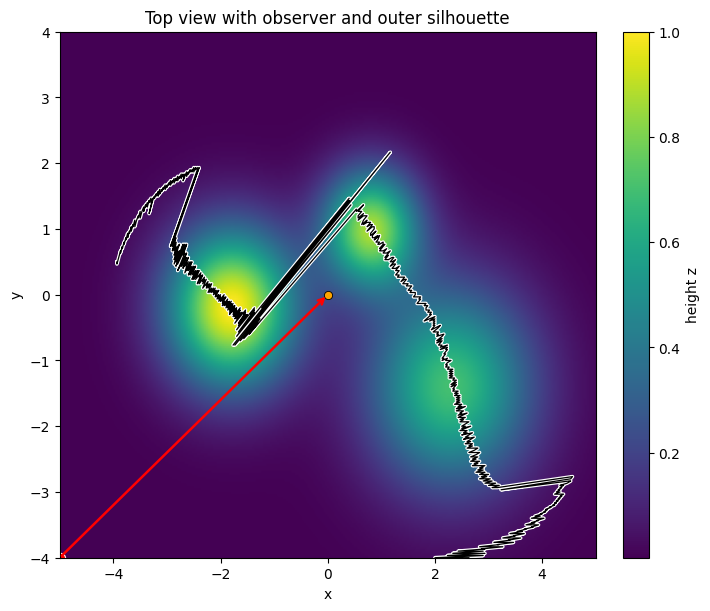

In [18]:
sil = extract_outer_silhouette_camera_smooth(
    x,
    y,
    Z,
    obs_x=x.min(),
    obs_y=y.min(),
    obs_z=1.0,
    target_x=0.0,
    target_y=0.0,
    target_z=0.0,
    n_u_bins=700,
    z_min_rel=0.03,
    smooth_sigma_bins=3.0,
)

plot_heatmap_with_silhouette(
    x,
    y,
    Z,
    sil,
    obs_x=x.min(),
    obs_y=y.min(),
    target_x=0.0,
    target_y=0.0,
)
plt.show()